# 🏠 HousePricePro – House Price Prediction (Regression)

## 📌 Project Overview

House price prediction is an important problem in the real estate industry. Accurate price estimation helps buyers, sellers, and real estate companies make informed decisions.

In this project, we build a **machine learning regression model** to predict house prices based on various features such as area, number of bedrooms, bathrooms, number of stories, and other property characteristics.

The goal is to analyze housing data and develop models that can accurately estimate property prices using historical information.

---

## 🎯 Objective

The main objectives of this project are:

* To explore and understand the housing dataset
* To preprocess and prepare the data for machine learning models
* To build regression models to predict house prices
* To compare multiple models and evaluate their performance
* To identify key features that influence house prices

---

## 🤖 Machine Learning Approach

This project applies **supervised machine learning techniques** for regression.

The following models are implemented:

* **Linear Regression** – Baseline model for price prediction
* **Ridge Regression** – Linear regression with L2 regularization
* **Lasso Regression** – Linear regression with L1 regularization for feature selection

These models help understand how different regularization techniques impact prediction performance.

---

## 📊 Evaluation Metrics

To evaluate the performance of the regression models, the following metrics are used:

* **RMSE (Root Mean Squared Error)** – Measures prediction error magnitude
* **R² Score (Coefficient of Determination)** – Measures how well the model explains the variance in house prices

---

## 🏁 Expected Outcome

By the end of this project, we aim to:

* Build a machine learning model capable of predicting house prices
* Identify the most important factors affecting housing prices
* Compare the performance of different regression models
* Provide insights that can help buyers, sellers, and real estate businesses make better pricing decisions


## 📂 Dataset & Imports

In this section, we import the required Python libraries and load the housing dataset.

The dataset contains features describing houses such as:

- Area
- Number of bedrooms
- Bathrooms
- Stories
- Parking
- Furnishing status

The target variable for our prediction model is **Price**.

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Set visualization style
sns.set_style("whitegrid")

In [4]:
# Load dataset
df = pd.read_csv("housing_dataset.csv")

# Display dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (545, 13)


In [5]:
# Display first 5 rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 🔎 Data Understanding

Before building machine learning models, it is important to understand the dataset.

In this section we explore the structure of the dataset by examining:

- Column names
- Data types
- Summary statistics
- Missing values

This helps identify potential data quality issues and understand the features available for prediction.

In [6]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


### Statistical Summary

Next, we examine summary statistics of the numerical features such as mean, standard deviation, minimum, and maximum values.

In [8]:
# Summary statistics
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Checking Missing Values

Missing values can negatively impact machine learning models, so we check whether any columns contain missing data.

In [9]:
# Check missing values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### Column Names

Finally, we list all columns in the dataset to clearly understand the available features.

In [10]:
# Display column names
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

## 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the patterns and relationships within the dataset.

In this section, we analyze the data using visualizations to identify:

- Distribution of house prices
- Relationships between features and price
- Correlations between variables

These insights help determine which features may influence house prices the most.

### Distribution of House Prices

First, we examine the distribution of house prices to understand how property values are spread across the dataset.

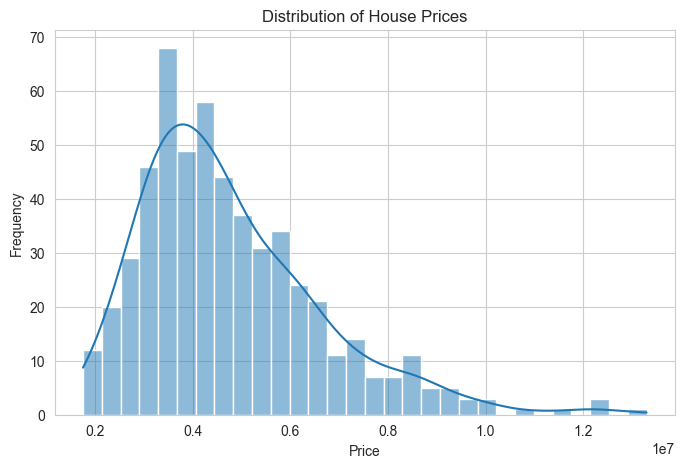

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Correlation Heatmap

A correlation heatmap helps identify relationships between numerical features and house prices.

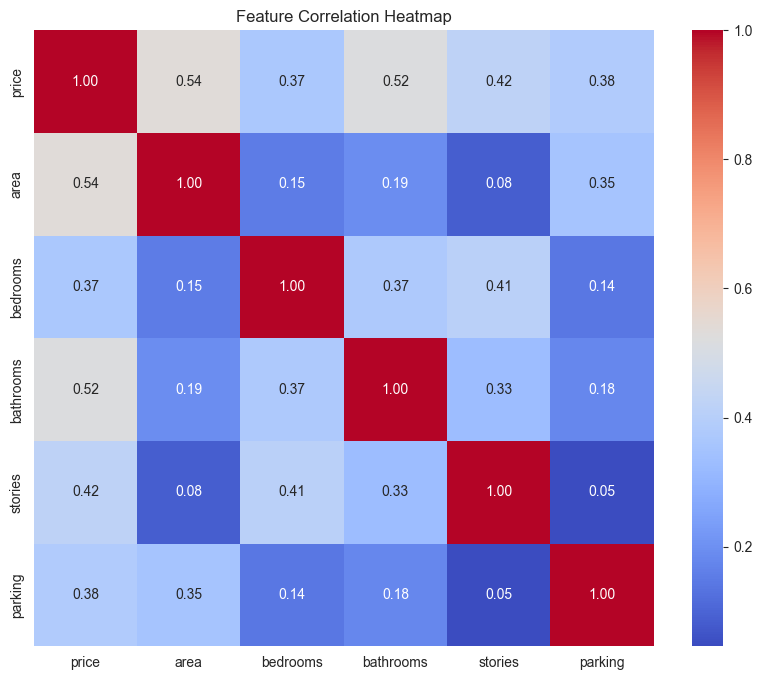

In [12]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Heatmap")

plt.show()

### Area vs Price

We expect houses with larger area to generally have higher prices.

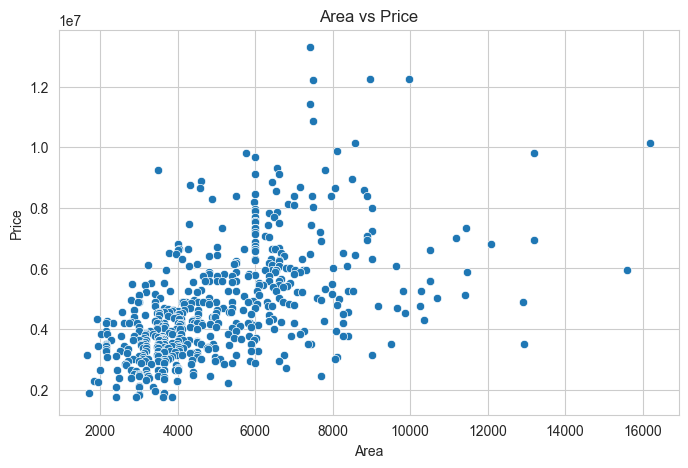

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="area", y="price", data=df)

plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

### Bedrooms vs Price

The number of bedrooms may influence the price of a house.

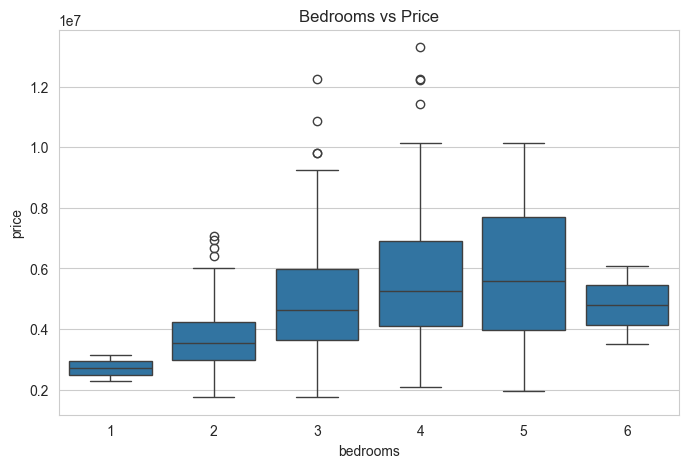

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x="bedrooms", y="price", data=df)

plt.title("Bedrooms vs Price")

plt.show()

### Bathrooms vs Price

We analyze whether houses with more bathrooms tend to have higher prices.

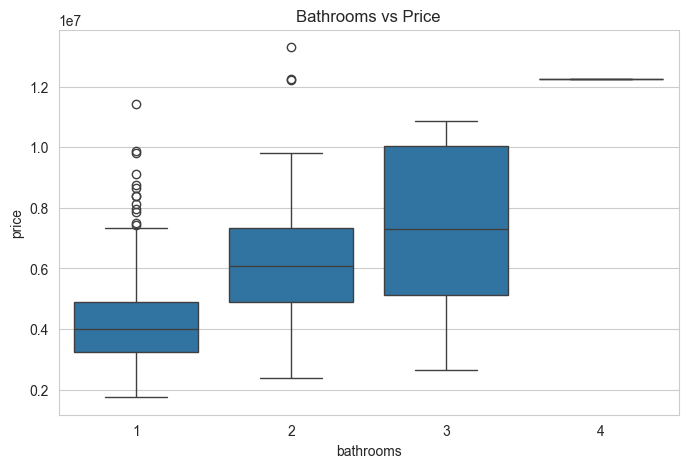

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x="bathrooms", y="price", data=df)

plt.title("Bathrooms vs Price")

plt.show()

### EDA Insights

From the exploratory analysis, several important patterns can be observed:

* **Price Distribution:**
  The distribution of house prices appears slightly right-skewed, indicating that most houses fall within a moderate price range while a smaller number of properties have significantly higher prices.

* **Area vs Price:**
  There is a clear positive relationship between house area and price. Larger houses generally tend to have higher prices.

* **Bedrooms vs Price:**
  Houses with more bedrooms tend to have higher prices on average, although the relationship is not perfectly linear due to other influencing factors.

* **Bathrooms vs Price:**
  The number of bathrooms shows a noticeable positive relationship with house prices. Properties with more bathrooms usually belong to higher price ranges.

* **Correlation Heatmap:**
  Among the numerical features, **area and bathrooms show the strongest correlation with price**, suggesting they may be important predictors in th


## 🧹 Data Preprocessing

Before training machine learning models, we perform basic preprocessing steps to ensure the dataset is clean and ready for modeling.

In this section we will:

- Check for duplicate records
- Inspect categorical variables
- Prepare the dataset for encoding and feature scaling

### Checking Duplicate Records

Duplicate rows can bias the model and affect training results.  
We check if the dataset contains duplicate entries.

In [16]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

### Identify Categorical Features

Next, we check which columns contain categorical data. These variables must be encoded before being used in machine learning models.

In [18]:
# Display data types
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

### Separate Features and Target Variable

The target variable for this project is **price**, which represents the selling price of a house.

All other columns will be used as input features for the regression models.

In [19]:
# Define target variable
y = df["price"]

# Define feature variables
X = df.drop("price", axis=1)

X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 🔢 Encoding Categorical Variables

Machine learning models require numerical input features. However, the dataset contains several categorical variables such as:

- mainroad
- guestroom
- basement
- hotwaterheating
- airconditioning
- prefarea
- furnishingstatus

To make these features usable for regression models, we convert them into numerical format using **One-Hot Encoding**.

In [20]:
# Apply one-hot encoding
X = pd.get_dummies(X, drop_first=True)

X.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,7420,4,1,2,2,True,True,True,False,True,False,False,False


### Encoded Feature Set

After encoding, categorical variables are converted into binary columns representing the presence or absence of each category.

This allows regression models to process categorical information effectively.

## ⚖️ Feature Scaling

Feature scaling is an important preprocessing step for many machine learning algorithms.

In this project, we apply **Standard Scaling** to normalize the feature values. This ensures that all features contribute equally during model training.

Feature scaling is particularly important for regularized regression models such as **Ridge Regression** and **Lasso Regression**, since these algorithms are sensitive to the magnitude of input features.

### Applying StandardScaler

We use **StandardScaler** to transform the features so that they have:

- Mean = 0
- Standard Deviation = 1

In [21]:
# Initialize scaler
scaler = StandardScaler()

# Fit and transform features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier interpretation
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.046726,1.403419,1.421812,1.378217,1.517692,0.405623,-0.465315,-0.734539,-0.219265,1.472618,1.804941,-0.844888,-0.696429
1,1.757010,1.403419,5.405809,2.532024,2.679409,0.405623,-0.465315,-0.734539,-0.219265,1.472618,-0.554035,-0.844888,-0.696429
2,2.218232,0.047278,1.421812,0.224410,1.517692,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.804941,1.183588,-0.696429
3,1.083624,1.403419,1.421812,0.224410,2.679409,0.405623,-0.465315,1.361397,-0.219265,1.472618,1.804941,-0.844888,-0.696429
4,1.046726,1.403419,-0.570187,0.224410,1.517692,0.405623,2.149083,1.361397,-0.219265,1.472618,-0.554035,-0.844888,-0.696429


### Scaled Feature Matrix

After scaling, all features are normalized to a similar range. This helps improve the performance and stability of regression models, especially those that use regularization.

## 🔀 Train-Test Split

To evaluate the performance of our regression models, we split the dataset into **training** and **testing** sets.

- **Training set:** Used to train the machine learning models
- **Testing set:** Used to evaluate model performance on unseen data

We use an **80-20 split**, meaning:
- 80% of the data is used for training
- 20% of the data is used for testing

In [22]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (436, 13)
Testing set shape: (109, 13)


### Dataset Split Summary

The dataset has now been divided into training and testing subsets.

The **training set** will be used to train our regression models, while the **testing set** will be used to evaluate how well the models generalize to unseen data.

## 📈 Linear Regression (Baseline Model)

Linear Regression is one of the simplest and most commonly used algorithms for regression problems.

It models the relationship between the input features and the target variable by fitting a linear equation.

In this section, we train a **Linear Regression model** to predict house prices. This model will serve as the **baseline**, allowing us to compare the performance of more advanced models such as Ridge and Lasso regression.

### Training the Model

We train the Linear Regression model using the training dataset.

In [23]:
# Initialize Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Making Predictions

After training the model, we use it to predict house prices on the test dataset.

In [24]:
# Predict on test data
y_pred_lr = lr_model.predict(X_test)

y_pred_lr[:5]

array([5164653.90033967, 7224722.29802166, 3109863.24240338,
       4612075.3272256 , 3294646.25725956])

### Model Evaluation

To evaluate the performance of the model, we calculate:

- **RMSE (Root Mean Squared Error)** – measures prediction error
- **R² Score** – measures how well the model explains variance in house prices

In [25]:
# Calculate RMSE
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Calculate R2 score
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2 Score:", r2_lr)

Linear Regression RMSE: 1324506.96009144
Linear Regression R2 Score: 0.6529242642153177


### Linear Regression Results

The Linear Regression model achieved the following performance:

* **RMSE:** 1,324,506
* **R² Score:** 0.653

The RMSE indicates the average prediction error in house price estimation. A lower RMSE generally indicates better model performance.

The **R² score of 0.653** means that approximately **65.3% of the variance in house prices is explained by the model** using the available features.

While this provides a reasonable baseline, linear regression can sometimes suffer from issues such as **multicollinearity** and **overfitting** when many correlated features are present.

In the next sections, we will apply **Ridge Regression** and **Lasso Regression**, which introduce regularization techniques to potentially improve model generalization and stability.


## 🧠 Ridge Regression (L2 Regularization)

Ridge Regression is a variation of Linear Regression that introduces **L2 regularization**.

Regularization adds a penalty term to the loss function, which discourages the model from assigning very large coefficients to features.

Benefits of Ridge Regression:

- Reduces model overfitting
- Handles multicollinearity between features
- Produces more stable predictions

In this section, we train a Ridge Regression model and compare its performance with the baseline Linear Regression model.

### Training the Ridge Regression Model

In [26]:
# Initialize Ridge Regression model
ridge_model = Ridge(alpha=1.0)

# Train the model
ridge_model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### Making Predictions

In [27]:
# Predict on test data
y_pred_ridge = ridge_model.predict(X_test)

y_pred_ridge[:5]

array([5162922.36465806, 7219683.82952353, 3111457.17281192,
       4612826.4059223 , 3296737.29577762])

### Model Evaluation

In [28]:
# Calculate RMSE
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# Calculate R2 score
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression RMSE:", rmse_ridge)
print("Ridge Regression R2 Score:", r2_ridge)

Ridge Regression RMSE: 1324676.9186519037
Ridge Regression R2 Score: 0.6528351861223267


### Ridge Regression Results

The Ridge Regression model achieved the following performance:

* **RMSE:** 1,324,677
* **R² Score:** 0.653

Compared to the baseline Linear Regression model, the performance of Ridge Regression is very similar. This suggests that the dataset does not suffer heavily from multicollinearity or overfitting.

Ridge Regression still provides a more stable model by applying **L2 regularization**, which penalizes large coefficients and helps control model complexity.

In the next section, we will implement **Lasso Regression**, which applies **L1 regularization** and can perform feature selection by shrinking some coefficients to zero.


## 🧠 Lasso Regression (L1 Regularization)

Lasso Regression is another regularized version of Linear Regression that applies **L1 regularization**.

L1 regularization adds a penalty proportional to the absolute value of the coefficients. This has an important effect: some coefficients can become exactly zero.

Advantages of Lasso Regression:

- Reduces overfitting
- Performs **automatic feature selection**
- Simplifies the model by removing less important features

In this section, we train a Lasso Regression model and evaluate its performance on the test dataset.

### Training the Lasso Regression Model

In [29]:
# Initialize Lasso model
lasso_model = Lasso(alpha=1.0)

# Train the model
lasso_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### Making Predictions

In [30]:
# Predict on test data
y_pred_lasso = lasso_model.predict(X_test)

y_pred_lasso[:5]

array([5164654.45544706, 7224717.4172372 , 3109866.96642492,
       4612077.53937833, 3294645.24212741])

### Model Evaluation

In [31]:
# Calculate RMSE
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# Calculate R2 score
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression RMSE:", rmse_lasso)
print("Lasso Regression R2 Score:", r2_lasso)

Lasso Regression RMSE: 1324507.439381222
Lasso Regression R2 Score: 0.652924013027685


### Lasso Regression Results

The Lasso Regression model achieved the following performance:

* **RMSE:** 1,324,507
* **R² Score:** 0.653

The performance of Lasso Regression is nearly identical to that of Linear Regression. This indicates that applying L1 regularization did not significantly improve predictive performance for this dataset.

This suggests that the dataset does not contain strong multicollinearity or redundant features that require aggressive regularization.

However, Lasso Regression still provides value by **simplifying the model and potentially identifying less important features through coefficient shrinkage**.

In the next section, we will compare the performance of **all three models** to determine which model performs best.


## 📊 Model Evaluation & Comparison

After training three regression models — **Linear Regression**, **Ridge Regression**, and **Lasso Regression** — we now compare their performance.

The models are evaluated using the following metrics:

- **RMSE (Root Mean Squared Error)** – measures the average prediction error
- **R² Score** – measures how well the model explains the variance in house prices

Lower RMSE and higher R² values indicate better model performance.

In [32]:
# Create comparison table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "RMSE": [rmse_lr, rmse_ridge, rmse_lasso],
    "R2 Score": [r2_lr, r2_ridge, r2_lasso]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,1.324507e+06,0.652924
1,Ridge Regression,1.324677e+06,0.652835
2,Lasso Regression,1.324507e+06,0.652924


### Model Performance Visualization

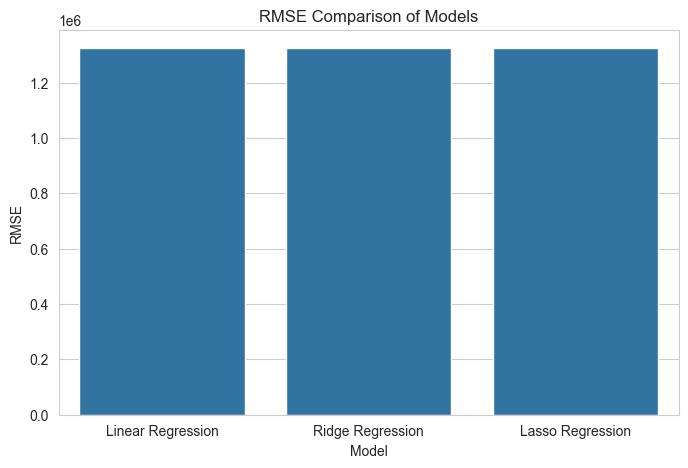

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="RMSE", data=results)

plt.title("RMSE Comparison of Models")
plt.ylabel("RMSE")
plt.xlabel("Model")

plt.show()

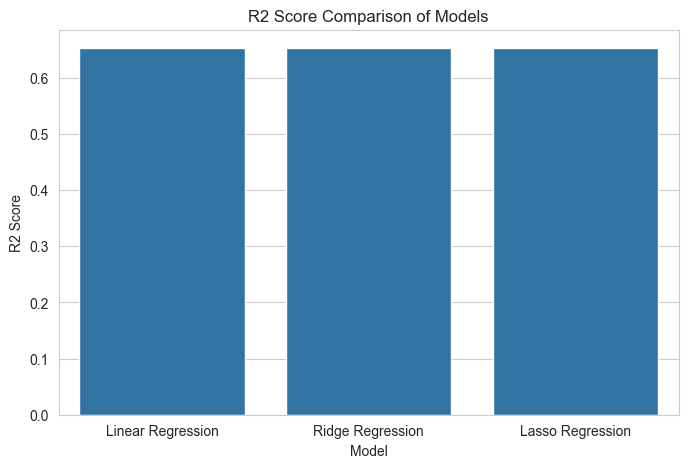

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="R2 Score", data=results)

plt.title("R2 Score Comparison of Models")
plt.ylabel("R2 Score")
plt.xlabel("Model")

plt.show()

### Model Comparison Summary

From the comparison results, we observe that **Linear Regression, Ridge Regression, and Lasso Regression produce nearly identical performance**.

* **Linear Regression RMSE:** 1,324,507
* **Ridge Regression RMSE:** 1,324,677
* **Lasso Regression RMSE:** 1,324,507

The **R² score for all models is approximately 0.653**, meaning the models explain about **65% of the variance in house prices**.

The similarity in performance suggests that:

* The dataset does not contain severe **multicollinearity**
* Regularization does not significantly improve predictive performance
* The baseline **Linear Regression model is already sufficient for this dataset**

Therefore, while Ridge and Lasso provide regularization benefits, **Linear Regression performs comparably while remaining simpler and easier to interpret**.


## 💼 Business Insights

Based on the exploratory data analysis and regression modeling, several practical insights can be derived from the housing dataset.

### Key Factors Influencing House Prices

The analysis indicates that structural characteristics of a house strongly influence its price. In particular:

* **Area** has one of the strongest relationships with price. Larger houses generally command higher market values.
* **Bathrooms** show a strong positive influence on price. Properties with more bathrooms tend to belong to higher price ranges.
* **Bedrooms** also contribute to price growth, although the relationship is slightly weaker compared to area and bathrooms.

### Property Features and Value

Additional property features such as **parking availability, number of stories, and preferred area location** also contribute to higher house prices. These features improve property attractiveness and market demand.

### Implications for Real Estate Businesses

The insights from this model can help:

* **Real estate agencies** estimate competitive pricing for properties.
* **Property developers** understand which features increase property value.
* **Home buyers and investors** identify properties with strong value drivers.

By leveraging machine learning models, real estate companies can make **data-driven pricing decisions**, improve valuation accuracy, and better understand market trends.


## 🏁 Conclusion

In this project, we developed a machine learning pipeline to predict house prices using a housing dataset containing various property features.

The project followed a structured workflow:

1. **Data Understanding and Exploration** to analyze feature distributions and relationships with house prices.
2. **Data Preprocessing** to prepare the dataset for machine learning models.
3. **Encoding and Feature Scaling** to transform categorical variables and normalize feature values.
4. **Model Training** using three regression algorithms:

   * Linear Regression
   * Ridge Regression
   * Lasso Regression
5. **Model Evaluation and Comparison** using RMSE and R² score.

The results showed that all three models produced very similar performance, with an **R² score of approximately 0.65**, meaning the models explain around **65% of the variance in house prices**.

Among the models, **Linear Regression performed competitively while remaining simple and interpretable**, making it a practical choice for this dataset.

Overall, the project demonstrates how regression models can be applied to housing data to estimate property prices and uncover key factors that influence market value.

This approach can assist **real estate companies, property investors, and home buyers** in making more informed and data-driven decisions.
